# Paper's Pipeline

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import pearsonr, beta as _beta_dist

from leaspy.io.data import Data
from leaspy.models import JointModel
from leaspy.datasets import load_dataset

warnings.filterwarnings("ignore", category=UserWarning)

## Reference model (source of true $\theta$)

The reference model is fitted once on the original data. Its parameters play the role of **true $\theta$** for the
simulation study, every simulated dataset will be generated from this model.

In [2]:
M          = 50
N          = 50    
N_ITER     = 500   
N_PERSO    = 500   
NB_EVENTS  = 1
SAVE_PATH  = os.path.join("..", "output", "simulation_study.pkl")

In [3]:
# Load original data and create visit parameters for simulation
data = Data.from_dataframe(load_dataset("simulated_data_for_joint"), "joint")
df_orig = data.to_dataframe()
print(f"Original data: {df_orig.shape[0]} rows, {df_orig['ID'].nunique()} patients")

# Visit parameters are automatically estimated from the original data.
visit_params = {
    "patient_number": N,
    "visit_type": "random",
    "data": data,
}

Original data: 157 rows, 17 patients


In [4]:
# Fit reference model on original data to get "true" parameters theta
ref_model = JointModel.load("../models/model_on_simulated_data_for_joint_10000_iterations.json")
FEATURES = ref_model.features

theta_true = {
    k: v.detach().cpu().numpy().copy()
    for k, v in ref_model.parameters.items()
}

print("True parameters theta (reference model):")
for k, v in theta_true.items():
    print(f"  {k:25s}: {np.atleast_1d(v).tolist()}")

True parameters theta (reference model):
  betas_mean               : [[-0.04789818078279495, -0.12371701002120972], [-0.019805774092674255, -0.07074471563100815], [-0.11540009081363678, -0.0037251838948577642]]
  log_g_mean               : [0.12425749003887177, 3.2550899982452393, 2.8469231128692627, 1.4333739280700684]
  log_rho_mean             : [-0.3370297849178314]
  log_v0_mean              : [-3.2611074447631836, -4.210326671600342, -4.0068864822387695, -2.9076921939849854]
  n_log_nu_mean            : [-1.234789490699768]
  noise_std                : [0.0895705372095108]
  tau_mean                 : [78.98753356933594]
  tau_std                  : [5.939133167266846]
  xi_std                   : [0.5409743785858154]
  zeta_mean                : [[0.2863364517688751], [-0.36348390579223633]]


## Simulation study loop

For each repetition m = 1, …, M:
1. Simulate a dataset of N patients from the reference model.
2. Fit a fresh `JointModel` on this simulated dataset.
3. Personalise to recover individual parameters.

In [5]:
from IPython.utils import io

with io.capture_output() as captured:
    if os.path.exists(SAVE_PATH):
        with open(SAVE_PATH, "rb") as f:
            results = pickle.load(f)
        print(f"Loaded {len(results['pop_params'])} results from {SAVE_PATH}")
    else:
        results = {
            "pop_params": [],   # list of M dicts {param_name: np.ndarray}
            "true_ips":   [],   # list of M DataFrames with columns xi, tau (from simulation)
            "est_ips":    [],   # list of M DataFrames with columns xi, tau (from personalisation)
        }

        # Number of digits needed so zero-padded IDs sort lexicographically == numerically.
        # e.g. N=50 → 2 digits: "00","01",...,"49"  (avoids "0","1","10","11",... ordering)
        _n_digits = len(str(N - 1))

        for m in tqdm(range(M), desc="Simulation study"):

            # Simulate a dataset with the reference model
            np.random.seed(m)
            torch.manual_seed(m)

            sim_result = ref_model.simulate(
                algorithm="joint_simulate",
                features=FEATURES,
                visit_parameters=visit_params,
            )
            sim_data = sim_result.data

            # Rename IDs to zero-padded strings so that groupby("ID").min() inside
            # JointModel's Weibull initialisation produces the same patient order as
            # dataset.event_time (which uses insertion order).
            _df_sim = sim_data.to_dataframe()
            _id_map = {old: old.zfill(_n_digits) for old in _df_sim["ID"].unique()}
            _df_sim["ID"] = _df_sim["ID"].map(_id_map)
            sim_data = Data.from_dataframe(_df_sim, "joint", factory_kws={"nb_events": NB_EVENTS})

            # individual_parameters from simulate is a DataFrame [xi, tau, ...]
            ip_sim = sim_result.individual_parameters
            true_ip_df = ip_sim if isinstance(ip_sim, pd.DataFrame) else pd.DataFrame(ip_sim)
            true_ip_df.index = true_ip_df.index.map(lambda x: x.zfill(_n_digits))

            # Fit a new model on the simulated data to recover population parameters
            new_model = JointModel(name=f"m{m}", nb_events=NB_EVENTS)
            try:
                new_model.fit(
                    sim_data, "mcmc_saem",
                    seed=1000 + m, n_iter=N_ITER, progress_bar=False,
                )
            except Exception as exc:
                print(f"  [m={m}] Fit failed: {exc}")
                continue
            est_params = {
                k: v.detach().cpu().numpy().copy()
                for k, v in new_model.parameters.items()
            }
            results["pop_params"].append(est_params)

            # Personalise the new model to recover individual parameters and compare
            try:
                est_ip = new_model.personalize(
                    sim_data, "mean_posterior",
                    seed=2000 + m, n_iter=N_PERSO, progress_bar=False,
                )
                results["est_ips"].append(est_ip.to_dataframe())
                results["true_ips"].append(true_ip_df)
            except Exception as exc:
                print(f"  [m={m}] Personalisation failed: {exc}")
                results["est_ips"].append(None)
                results["true_ips"].append(None)

        with open(SAVE_PATH, "wb") as f:
            pickle.dump(results, f)
        print(f"Results saved to {SAVE_PATH}")

## Model parameter metrics (RB, RRMSE, REE, RSE)

$$
REE(m) = \frac{\hat{\theta}^{(m)}-\theta}{\theta} \times 100 \qquad
RB(\hat\theta) = \frac{1}{M}\sum_m REE(m) \qquad
RRMSE(\hat\theta) = \sqrt{\frac{1}{M}\sum_m REE(m)^2}
$$

$$
SE_{emp}(\hat\theta) = \sqrt{\frac{\sum_m(\hat\theta^{(m)}-\bar{\hat\theta})^2}{M-1}}
\qquad
RSE_{emp}(\hat\theta) = \frac{SE_{emp}(\hat\theta)}{\bar{\hat\theta}}
$$

In [6]:
def clopper_pearson_ci(k, n, alpha=0.05):
    """Exact Clopper-Pearson 95 % CI for a binomial proportion k/n."""
    lo = _beta_dist.ppf(alpha / 2,     k,     n - k + 1) if k > 0 else 0.0
    hi = _beta_dist.ppf(1 - alpha / 2, k + 1, n - k    ) if k < n else 1.0
    return lo, hi


def compute_metrics(theta_true_val, theta_hats, se_hats=None):
    """
    Compute performance metrics for a scalar estimand.

    Parameters
    ----------
    theta_true_val : float
        Known true value theta.
    theta_hats : array-like (M,)
        Estimates theta (m) from each of the M simulations.
    se_hats : array-like (M,) or None
        Within-simulation standard errors (required for CR).

    Returns
    -------
    dict with keys REE, RB, RRMSE, RSE (and optionally CR, CR_lo, CR_hi).
    RB / RRMSE / REE are in % (x100).  RSE is a dimensionless ratio.
    """
    theta_hats = np.asarray(theta_hats, dtype=float)

    ree   = (theta_hats - theta_true_val) / abs(theta_true_val) * 100
    rb    = float(ree.mean())
    rrmse = float(np.sqrt((ree ** 2).mean()))
    se_emp = float(theta_hats.std(ddof=1))
    rse    = float(se_emp / abs(theta_hats.mean()))   # ratio, no x100

    out = {"REE": ree, "RB": rb, "RRMSE": rrmse, "RSE": rse}

    if se_hats is not None:
        se_hats = np.asarray(se_hats, dtype=float)
        covered = (
            (theta_hats - 1.96 * se_hats <= theta_true_val) &
            (theta_true_val <= theta_hats + 1.96 * se_hats)
        )
        k = int(covered.sum())
        lo, hi = clopper_pearson_ci(k, len(theta_hats))
        out.update({"CR": k / len(theta_hats), "CR_lo": lo, "CR_hi": hi})

    return out

In [7]:

PARAM_LABELS = {
    "xi_std":        r"$\sigma_{\xi}$",
    "tau_mean":      r"$t_0$",
    "tau_std":       r"$\sigma_{\tau}$",
    "noise_std":     r"$\sigma$",
    "g":             r"$\tilde{g}$",
    "log_v0":        r"$\tilde{v}_0$",
    "n_log_nu_mean": r"$\tilde{\nu}$",
    "log_rho_mean":  r"$\tilde{\rho}$",
    "betas_mean":    r"$\beta$",
    "zeta_mean":     r"$\zeta$",
}

summary_rows = []
ree_dict     = {}
ree_groups   = {}  # {param_name: {label: ree_array}}

for param_name, theta_true_arr in theta_true.items():
    theta_true_flat = np.atleast_1d(np.array(theta_true_arr).ravel())

    # Collect estimates from each simulation
    hats_list = [
        np.atleast_1d(np.array(r[param_name]).ravel())
        for r in results["pop_params"]
        if param_name in r
    ]
    if not hats_list:
        continue
    hats_mat = np.array(hats_list)   # (M_actual, d)

    label_base = PARAM_LABELS.get(param_name, param_name)

    for comp_idx in range(len(theta_true_flat)):
        t = float(theta_true_flat[comp_idx])
        if abs(t) < 1e-10:
            continue   # avoid division by zero for near-zero true values

        hat_vec = hats_mat[:, comp_idx]
        label   = f"{label_base}[{comp_idx}]" if len(theta_true_flat) > 1 else label_base

        mets = compute_metrics(t, hat_vec)
        summary_rows.append({
            "Parameter":    label,
            "theta (true)":     round(t, 5),
            "theta mean (M)":  round(float(hat_vec.mean()), 5),
            "RB (%)":       round(mets["RB"],    3),
            "RRMSE (%)":    round(mets["RRMSE"], 3),
            "RSE":          round(mets["RSE"],   4),
        })
        ree_dict[label] = mets["REE"]
        ree_groups.setdefault(param_name, {})[label] = mets["REE"]

df_metrics = pd.DataFrame(summary_rows)
display(df_metrics)


,Parameter,theta (true),theta mean (M),RB (%),RRMSE (%),RSE
0,$\beta$[0],-0.04790,0.01045,121.822,221.182,8.5455
1,$\beta$[1],-0.12372,0.01242,110.036,134.199,7.7326
2,$\beta$[2],-0.01981,0.00207,110.437,300.398,27.0370
3,$\beta$[3],-0.07074,0.00511,107.226,144.133,13.4640
4,$\beta$[4],-0.11540,-0.00735,93.629,113.052,10.0458
5,$\beta$[5],-0.00373,-0.00217,41.758,1807.376,31.3388
6,log_g_mean[0],0.12426,0.38473,209.620,228.356,0.2955
7,log_g_mean[1],3.25509,3.48425,7.040,11.562,0.0866
8,log_g_mean[2],2.84692,3.22168,13.164,15.381,0.0710
9,log_g_mean[3],1.43337,1.99365,39.088,40.968,0.0891


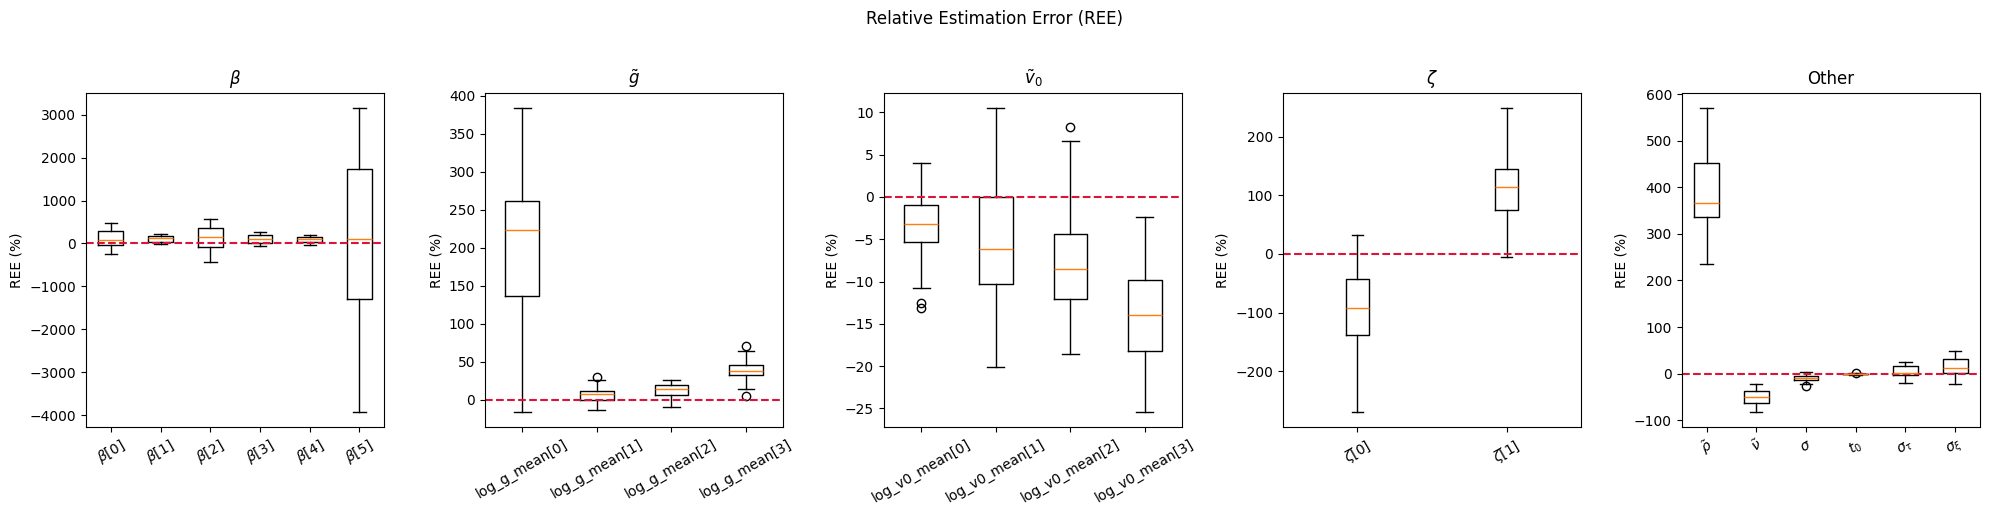

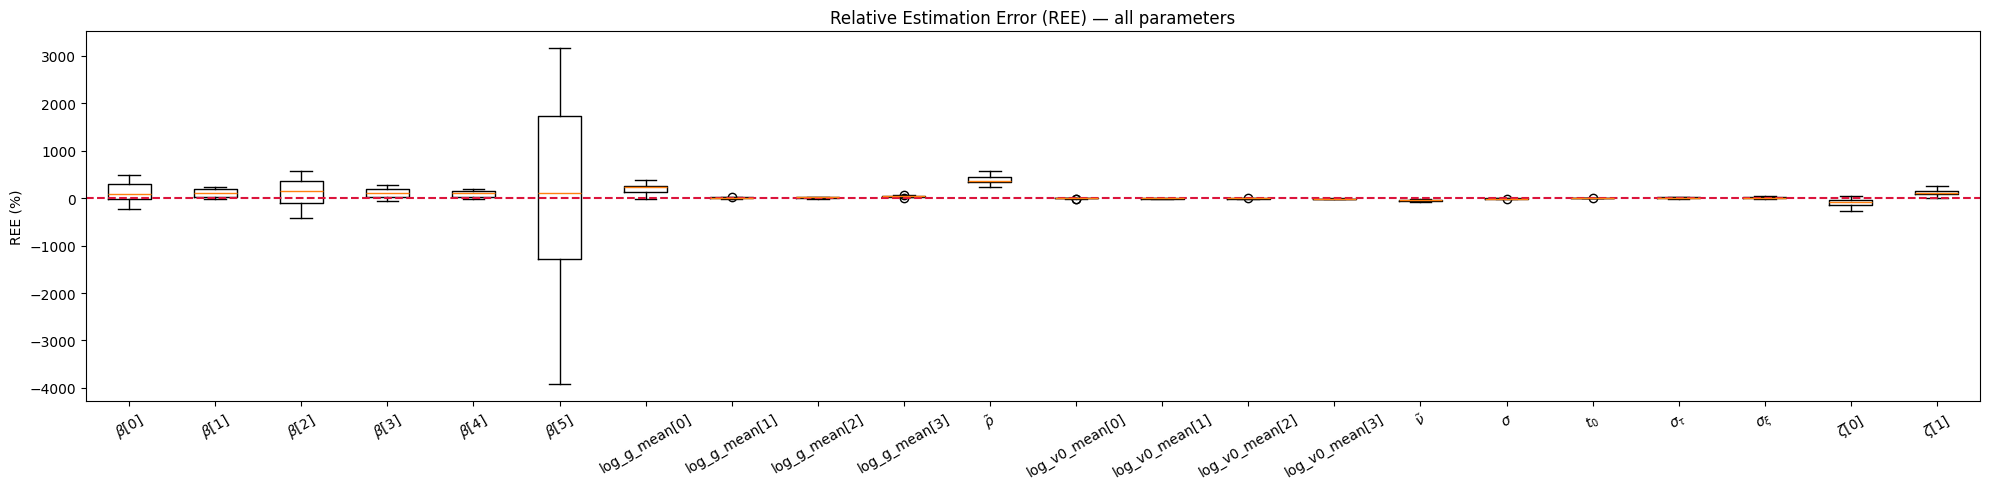

In [8]:

# REE boxplots by parameter group
GROUP_DEFS = [
    ("betas",  lambda p: "beta"   in p,                       r"$\beta$"),
    ("log_g",  lambda p: p in ("g", "log_g_mean"),            r"$\tilde{g}$"),
    ("log_v0", lambda p: p in ("log_v0", "log_v0_mean"),      r"$\tilde{v}_0$"),
    ("zeta",   lambda p: "zeta"   in p,                       r"$\zeta$"),
    ("rest",   lambda p: True,                                 "Other"),
]

seen = set()
subplot_data = []
for _, match_fn, title in GROUP_DEFS:
    d = {lbl: ree for pname, lbls in ree_groups.items()
         for lbl, ree in lbls.items() if match_fn(pname) and lbl not in seen}
    seen.update(d)
    if d:
        subplot_data.append((title, d))

if subplot_data:
    n = len(subplot_data)
    total_w = 4 * n

    # --- grouped subplots ---
    fig, axes = plt.subplots(1, n, figsize=(total_w, 5))
    if n == 1:
        axes = [axes]
    for ax, (title, d) in zip(axes, subplot_data):
        ax.boxplot(d.values(), tick_labels=d.keys(), vert=True)
        ax.axhline(0, color="crimson", linestyle="--", lw=1.5)
        ax.set_ylabel("REE (%)")
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=30)
    fig.suptitle("Relative Estimation Error (REE)", y=1.02)
    plt.tight_layout()
    plt.show()

    # --- all parameters in one plot ---
    fig, ax = plt.subplots(figsize=(total_w, 5))
    ax.boxplot(ree_dict.values(), tick_labels=ree_dict.keys(), vert=True)
    ax.axhline(0, color="crimson", linestyle="--", lw=1.5)
    ax.set_ylabel("REE (%)")
    ax.set_title("Relative Estimation Error (REE) — all parameters")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


## Random effects: ICC 

The estimation of the random effects is assessed using the **intraclass correlation**
between the personalised values and the true values used for simulation.

We use ICC(3,1) — two-way mixed-effects model, single rater, absolute agreement:

$$ICC(3,1) = \frac{MS_B - MS_E}{MS_B + (k-1)\,MS_E}, \quad k=2$$

For reference, the Pearson correlation (which measures association but not agreement) is also reported.

           ICC(3,1)     Pearson r
-----------------------------------
xi     0.745 +/- 0.072  0.758 +/- 0.066
tau    0.884 +/- 0.046  0.895 +/- 0.045


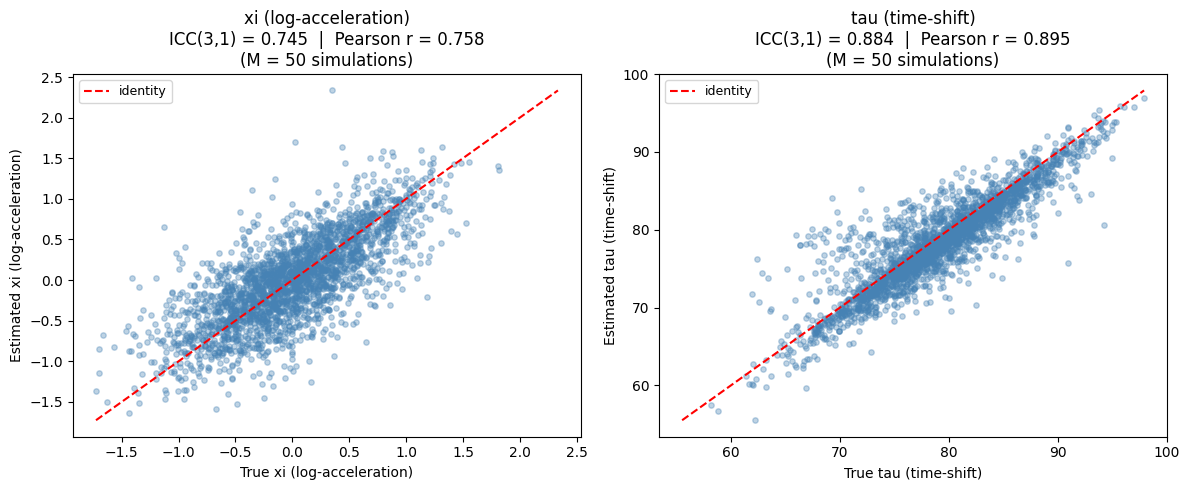

In [9]:
def icc_3_1(y_true, y_hat):
    """
    ICC(3,1) for k=2 raters (true vs estimated), absolute agreement.

    Parameters
    ----------
    y_true, y_hat : array-like of length n

    Returns
    -------
    float
    """
    y_true = np.asarray(y_true, dtype=float)
    y_hat  = np.asarray(y_hat,  dtype=float)
    n = len(y_true)
    if n < 3:
        return float("nan")
    k = 2
    y = np.stack([y_true, y_hat], axis=1)   # (n, 2)
    grand_mean = y.mean()
    row_means  = y.mean(axis=1)             # subject means
    ss_b = k * np.sum((row_means - grand_mean) ** 2)
    ss_e = np.sum((y - row_means[:, None]) ** 2)
    ms_b = ss_b / (n - 1)
    ms_e = ss_e / (n * (k - 1))
    return float((ms_b - ms_e) / (ms_b + (k - 1) * ms_e))


valid_pairs = [
    (t, e)
    for t, e in zip(results["true_ips"], results["est_ips"])
    if t is not None and e is not None
]

if not valid_pairs:
    print("No valid personalisation results — ICC cannot be computed.")
else:
    ip_cols  = ["xi", "tau"]
    ip_names = ["xi (log-acceleration)", "tau (time-shift)"]

    fig, axes = plt.subplots(1, len(ip_cols), figsize=(6 * len(ip_cols), 5))

    print(f"{'':5s}  {'ICC(3,1)':>12s}  {'Pearson r':>12s}")
    print("-" * 35)

    for ax, col, col_name in zip(axes, ip_cols, ip_names):
        icc_vals, r_vals = [], []
        all_true, all_hat = [], []

        for true_df, est_df in valid_pairs:
            # Align subjects by ID
            common = true_df.index.astype(str).intersection(est_df.index.astype(str))
            if len(common) < 3:
                continue
            yt = true_df.loc[true_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
            yh = est_df.loc[est_df.index.astype(str).isin(common),  col].to_numpy(dtype=float)

            all_true.append(yt)
            all_hat.append(yh)
            icc_vals.append(icc_3_1(yt, yh))
            if np.std(yt) > 0 and np.std(yh) > 0:
                r_vals.append(pearsonr(yt, yh)[0])

        at = np.concatenate(all_true)
        ah = np.concatenate(all_hat)

        ax.scatter(at, ah, alpha=0.35, s=15, color="steelblue")
        lo, hi = min(at.min(), ah.min()), max(at.max(), ah.max())
        ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="identity")
        ax.set_xlabel(f"True {col_name}")
        ax.set_ylabel(f"Estimated {col_name}")

        icc_m = np.nanmean(icc_vals)
        r_m   = np.nanmean(r_vals) if r_vals else float("nan")
        ax.set_title(
            f"{col_name}\nICC(3,1) = {icc_m:.3f}  |  Pearson r = {r_m:.3f}\n"
            f"(M = {len(valid_pairs)} simulations)"
        )
        ax.legend(fontsize=9)

        icc_s = np.nanstd(icc_vals)
        r_s   = np.nanstd(r_vals) if r_vals else float("nan")
        print(f"{col:5s}  {icc_m:.3f} +/- {icc_s:.3f}  {r_m:.3f} +/- {r_s:.3f}")

    plt.tight_layout()
    plt.show()